# Monte Carlo slab transport — analysis

Reads `results.csv` (produced by `./neutron`) and generates the three figures used in the README:

1. **Beer–Lambert anchor** — pure-absorber transmission against the exact $e^{-L}$ law
2. **TRA fractions vs $c$** — the physics the simulation exists to compute
3. **Convergence** — absolute error vs $N$ against the binomial standard-error envelope

Every tally is a binomial estimate over $N$ independent histories, so each fraction $p$ carries a standard error $\sqrt{p(1-p)/N}$.

In [2]:
# Imports 
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

df = pd.read_csv("results.csv")
df

,c,L,N,seed,transmitted,reflected,absorbed,T_frac,R_frac,A_frac,T_err,R_err,A_err
0,0.0,1,1000000,42,367632,0,632368,0.367632,0.000000,0.632368,0.000482,0.000000,0.000482
1,0.0,2,1000000,42,135874,0,864126,0.135874,0.000000,0.864126,0.000343,0.000000,0.000343
2,0.0,3,1000000,42,49744,0,950256,0.049744,0.000000,0.950256,0.000217,0.000000,0.000217
3,0.0,4,1000000,42,18404,0,981596,0.018404,0.000000,0.981596,0.000134,0.000000,0.000134
4,0.0,5,1000000,42,6619,0,993381,0.006619,0.000000,0.993381,0.000081,0.000000,0.000081
5,0.1,5,1000000,42,7360,16444,976196,0.007360,0.016444,0.976196,0.000085,0.000127,0.000152
6,0.2,5,1000000,42,8074,35106,956820,0.008074,0.035106,0.956820,0.000089,0.000184,0.000203
7,0.3,5,1000000,42,9129,57143,933728,0.009129,0.057143,0.933728,0.000095,0.000232,0.000249
8,0.4,5,1000000,42,10708,83254,906038,0.010708,0.083254,0.906038,0.000103,0.000276,0.000292
9,0.5,5,1000000,42,13019,115569,871412,0.013019,0.115569,0.871412,0.000113,0.000320,0.000335


## 1. Beer–Lambert validation

For a pure absorber ($c = 0$) every collision kills, so transmitting requires crossing the whole slab
without a single collision. The exact probability is $T = e^{-L}$, and reflection is impossible
($R \equiv 0$) because turning around requires a scatter. Points are Monte Carlo tallies at
$N = 10^6$ with binomial error bars; the curve is the exact law.

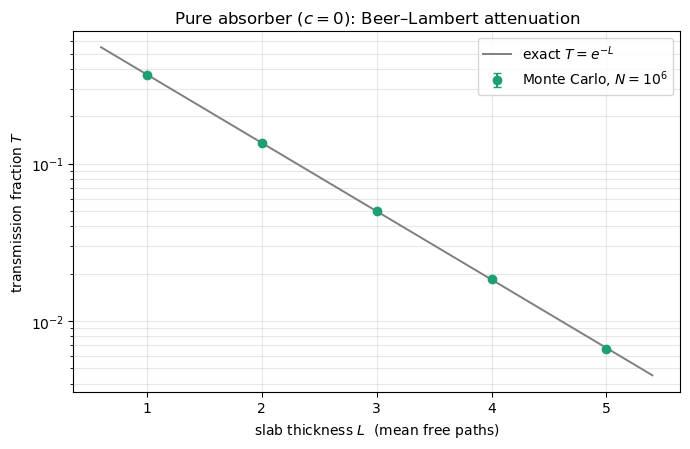

In [3]:
sub = df[(df["c"] == 0.0) & (df["N"] == 1_000_000)].sort_values("L")

Lgrid = np.linspace(0.6, 5.4, 200)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(Lgrid, np.exp(-Lgrid), color="tab:gray", lw=1.4, label=r"exact $T = e^{-L}$")
ax.errorbar(sub["L"], sub["T_frac"], yerr=sub["T_err"], fmt="o", ms=6, capsize=3,
            color="#1D9E75", zorder=3, label=r"Monte Carlo, $N = 10^6$")
ax.set_yscale("log")
ax.set_xlabel("slab thickness $L$  (mean free paths)")
ax.set_ylabel("transmission fraction $T$")
ax.set_title("Pure absorber ($c = 0$): Beer–Lambert attenuation")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig("figures/beer_lambert.png", dpi=150)
plt.show()

Deviations in units of the standard error.

In [4]:
z = df[(df["c"] == 0.0) & (df["N"] == 1_000_000)].copy()
z["exact"] = np.exp(-z["L"])
z["z_score"] = (z["T_frac"] - z["exact"]) / z["T_err"]
z[["L", "N", "T_frac", "exact", "T_err", "z_score"]].reset_index(drop=True).round(6)

,L,N,T_frac,exact,T_err,z_score
0,1,1000000,0.367632,0.367879,0.000482,-0.513193
1,2,1000000,0.135874,0.135335,0.000343,1.572185
2,3,1000000,0.049744,0.049787,0.000217,-0.198092
3,4,1000000,0.018404,0.018316,0.000134,0.657414
4,5,1000000,0.006619,0.006738,0.000081,-1.466896


## 2. TRA vs scattering probability

Intermediate $c$ has no closed-form answer which is why we must simulate.
Scattering opens a second channel through the slab: particles that would have died on their first
collision can now random-walk their way out of either face. Between $c = 0$ and $c = 1$,
transmission rises roughly $40\times$ and absorption collapses to exactly zero.

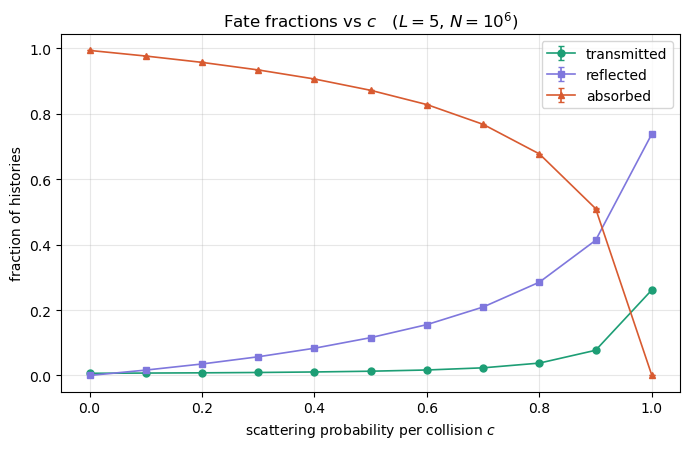

In [6]:
sw = df[(df["L"] == 5.0) & (df["N"] == 1_000_000)].sort_values("c")
assert np.allclose(sw[["T_frac", "R_frac", "A_frac"]].sum(axis=1), 1.0)

fig, ax = plt.subplots(figsize=(7, 4.6))
for col, err, label, marker, color in [
    ("T_frac", "T_err", "transmitted", "o", "#1D9E75"),
    ("R_frac", "R_err", "reflected",   "s", "#7F77DD"),
    ("A_frac", "A_err", "absorbed",    "^", "#D85A30"),
]:
    ax.errorbar(sw["c"], sw[col], yerr=sw[err], fmt=marker + "-", ms=5, lw=1.2,
                capsize=2, color=color, label=label)
ax.set_xlabel("scattering probability per collision $c$")
ax.set_ylabel("fraction of histories")
ax.set_title("Fate fractions vs $c$   ($L = 5$, $N = 10^6$)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("figures/fates_vs_c.png", dpi=150)
plt.show()

## 3. Convergence: the $1/\sqrt{N}$ law

At $c = 0$, $L = 2$ the exact answer $e^{-2}$ is known, so the absolute error of a single run
can be tracked as $N$ grows. Each point is one seed-42 experiment; the gray line is the binomial
standard error $\sqrt{p(1-p)/N}$. Error $\propto 1/\sqrt{N}$.

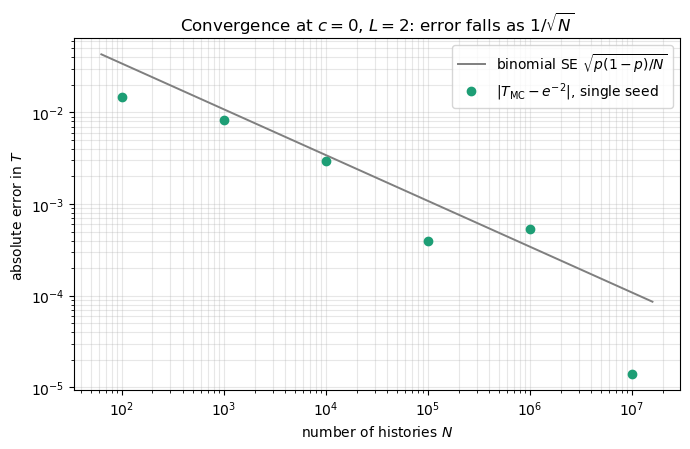

In [7]:
cv = df[(df["c"] == 0.0) & (df["L"] == 2.0)].sort_values("N")
exact = np.exp(-2.0)
abs_err = (cv["T_frac"] - exact).abs()

Ngrid = np.logspace(1.8, 7.2, 100)
envelope = np.sqrt(exact * (1.0 - exact) / Ngrid)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.loglog(Ngrid, envelope, color="tab:gray", lw=1.4,
          label=r"binomial SE $\sqrt{p(1-p)/N}$")
ax.loglog(cv["N"], abs_err, "o", ms=6, color="#1D9E75",
          label=r"$|T_{\mathrm{MC}} - e^{-2}|$, single seed")
ax.set_xlabel("number of histories $N$")
ax.set_ylabel("absolute error in $T$")
ax.set_title(r"Convergence at $c = 0$, $L = 2$: error falls as $1/\sqrt{N}$")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
fig.savefig("figures/convergence.png", dpi=150)
plt.show()